# Lab 7

## Introduction

Modify the class notebook to train an MLP model on top of embeddings extracted
from a representation model on the MagnaTagATune (MTAT) dataset.
1. Adapt the provided implementation and train the model on MTAT
* You can reuse the data loading code from the previous assignment.
2. Evaluate the classification performance.
* Should include ROC-AUC, and PR-AUC scores.
3. Write a short report documenting your decisions and observations
* The report should be included in the notebook
* The notebook should be self-explanatory, and executable (i.e., it should contain the code to install dependencies and setup the dataset). The assignment will be entirely evaluated on the contents of the notebook.

## Imports

In [29]:
!pip install omar_rq -q
!pip install torchmetrics -q

In [62]:
import math
import random
from pathlib import Path
import os
from google.colab import drive
from google.colab import files
import zipfile

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, Dataset
from torchaudio.transforms import MelSpectrogram, Resample
from tqdm.auto import tqdm, trange
from omar_rq import get_model
import torchaudio
import pandas as pd
import librosa

# Metrics
import torchmetrics

In [20]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

## Data Importing

### Importing Tags

In [10]:
if not os.path.isdir("/content/drive"):
  drive.mount('/content/drive')

In [21]:
try:
  df = pd.read_csv('/content/drive/MyDrive/SMC/MLSM/Lab3/annotations_final.csv', sep="\t", index_col=0)
except FileNotFoundError:
  uploaded = files.upload()
  df = pd.read_csv(list(uploaded.keys())[0], skipinitialspace = True)
except Exception as e:
  print(f"An error occurred: {e}")
  df = None

if df is not None:
    print(df.head())

         no voice  singer  duet  plucking  hard rock  world  bongos  \
clip_id                                                               
2               0       0     0         0          0      0       0   
6               0       0     0         0          0      0       0   
10              0       0     0         0          0      0       0   
11              0       0     0         0          0      0       0   
12              0       0     0         0          0      0       0   

         harpsichord  female singing  clasical  ...  rap  metal  hip hop  \
clip_id                                         ...                        
2                  0               0         0  ...    0      0        0   
6                  0               0         0  ...    0      0        0   
10                 0               0         0  ...    0      0        0   
11                 0               0         0  ...    0      0        0   
12                 0               0         0

### Importing Audios

In [14]:
FINAL_ZIP_NAME = 'magna_tag_atune_complete.zip'
DESTINATION_FOLDER = 'dataset'
BASE_PATH = '/content/drive/MyDrive/SMC/MLSM/Lab3' # Set this to the directory where your .001 files are located

with zipfile.ZipFile(os.path.join(BASE_PATH, FINAL_ZIP_NAME), 'r') as zf:
    zf.extractall(DESTINATION_FOLDER)

print(f"Success! All audio clips have been extracted to: {DESTINATION_FOLDER}")

Success! All audio clips have been extracted to: dataset


## Datasets

### Selecting Top 50 Tags

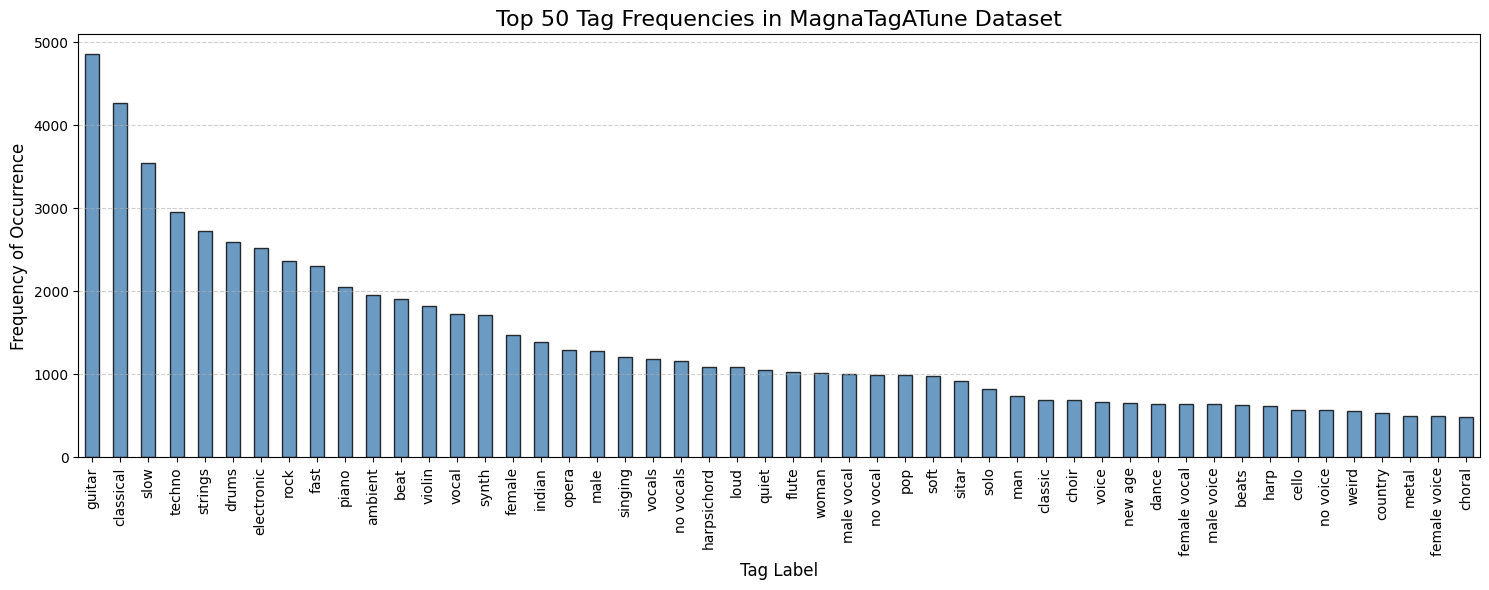

In [22]:
# 1. Calculate and select the top 50 tag counts
# df.iloc[:, :-1] selects all columns except the last one (assuming the last one is NOT a tag, e.g., clip_id)
tag_counts = df.iloc[:, :-1].sum().sort_values(ascending=False)
top_50_counts = tag_counts[:50]

# 2. Configure plot aesthetics
plt.figure(figsize=(15, 6)) # Better aspect ratio for bars

# 3. Create the bar plot directly
ax = top_50_counts.plot.bar(
    rot=90,             # Rotate x-labels for readability
    color='steelblue',  # Set a nice color
    edgecolor='k',      # Black border for clarity
    alpha=0.8
)

# 4. Set labels and title
ax.set_title('Top 50 Tag Frequencies in MagnaTagATune Dataset', fontsize=16)
ax.set_xlabel('Tag Label', fontsize=12)
ax.set_ylabel('Frequency of Occurrence', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.6) # Add light grid lines

plt.tight_layout()
plt.show()

In [23]:
top_50_counts.index

Index(['guitar', 'classical', 'slow', 'techno', 'strings', 'drums',
       'electronic', 'rock', 'fast', 'piano', 'ambient', 'beat', 'violin',
       'vocal', 'synth', 'female', 'indian', 'opera', 'male', 'singing',
       'vocals', 'no vocals', 'harpsichord', 'loud', 'quiet', 'flute', 'woman',
       'male vocal', 'no vocal', 'pop', 'soft', 'sitar', 'solo', 'man',
       'classic', 'choir', 'voice', 'new age', 'dance', 'female vocal',
       'male voice', 'beats', 'harp', 'cello', 'no voice', 'weird', 'country',
       'metal', 'female voice', 'choral'],
      dtype='object')

In [24]:
df_top50 = df[[c for c in top_50_counts.index] + ['mp3_path']]
df_top50.shape

(25863, 51)

In [25]:
tags = df.drop(columns=["mp3_path"]).columns.tolist()
df.apply(
    lambda row: row[tags][row[tags] == 1].index.tolist(),
    axis=1
)

,0
clip_id,
2,"[classical, strings, opera, violin]"
6,"[classical, violins, strings, classic, opera, ..."
10,"[classical, classic, opera]"
11,"[quiet, opera]"
12,"[classical, violins, strings, classic, violin]"
...,...
58899,"[guitar, classical guitar]"
58906,"[guitar, solo, strings, medieval, harp, slow, ..."
58907,"[classical, guitar, strings, slow]"


In [26]:
df.shape, df_top50.shape

((25863, 189), (25863, 51))

### Generate Datasets

In [67]:
class MTATOMARRQDataset(Dataset):
    """
    All-in-one dataset that:
    1. Filters MTAT by subset (train/val/test) based on folders.
    2. Loads audio and pre-computes OMAR-RQ embeddings.
    3. Serves embeddings for MLP training.
    """
    def __init__(self, root_dir, annotations_df, subset='train', device='cuda', sample_rate=16000):
        self.root_dir = root_dir
        self.device = device
        self.sample_rate = sample_rate # OMAR-RQ usually expects 16k or 48k, check model specs.
        self.duration = 3.0 # Duration in seconds
        self.n_samples = int(self.sample_rate * self.duration)

        # --- 1. SUBSET SELECTION LOGIC ---
        self.split_map = {
            'train': [str(i) for i in range(10)] + ['a', 'b'], # 0-9, a, b
            'val': ['c'],
            'test': ['d', 'e', 'f']
        }

        if subset not in self.split_map:
            raise ValueError(f"Invalid subset: '{subset}'. Options: {list(self.split_map.keys())}")

        target_folders = set(self.split_map[subset])

        # Filter DataFrame based on folder prefix
        self.subset_df = annotations_df[annotations_df['mp3_path'].apply(
            lambda x: x.split('/')[0] in target_folders
        )].copy().reset_index(drop=True)

        # Prepare labels
        # Assuming columns: 'mp3_path', 'clip_id', tag1, tag2...
        self.label_columns = self.subset_df.drop(columns=['mp3_path', 'clip_id'], errors='ignore').columns
        self.labels = self.subset_df[self.label_columns].values.astype(np.float32)
        self.paths = self.subset_df['mp3_path'].tolist()

        print(f"Dataset '{subset}' initialized. Processing {len(self.paths)} clips...")

        # --- 2. LOAD OMAR-RQ MODEL ---
        print("Loading OMAR-RQ model for extraction...")
        # Note: 'clap_omarrq_mp_small_music' usually works best with 16kHz or 48kHz depending on config
        self.model = get_model(model_id="mtg-upf/clap_omarrq_mp_small_music", device=self.device)
        self.model.eval()
        self.layers = [6] # Intermediate layer

        # --- 3. EXTRACT AND CACHE EMBEDDINGS ---
        self.cached_embeddings = []


        # We process the list internally to avoid needing an external AudioDataset class
        with torch.no_grad():
            for i in tqdm(range(len(self.paths)), desc=f"Extracting {subset}"):

                # A. Load Audio
                audio_tensor = self._load_audio_robust(self.paths[i])
                audio_tensor = audio_tensor.unsqueeze(0).to(self.device) # [1, Samples]

                # B. Extract Features
                # Output: [Batch, Time, Dim]
                emb_map = self.model.extract_embeddings(audio_tensor, layers=self.layers)

                if emb_map.dim() == 4:
                    emb_map = emb_map.squeeze(1)

                # C. Global Average Pooling (Time Dimension = 1)
                # We want one vector per song: [Dim]
                emb_vector = torch.mean(emb_map, dim=1).squeeze().cpu()

                self.cached_embeddings.append(emb_vector)

        # --- 4. CLEANUP ---
        # Delete model to free GPU memory for the MLP
        del self.model
        torch.cuda.empty_cache()
        print(f"Finished. Cached {len(self.cached_embeddings)} embeddings.")

    def _load_audio_robust(self, mp3_rel_path):
        full_path = os.path.join(self.root_dir, mp3_rel_path)

        if not os.path.exists(full_path):
            # Ahora sí devolvemos ceros si no existe, pero imprime un aviso si quieres
            # print(f"Missing: {full_path}")
            return torch.zeros(self.n_samples)

        try:
            # --- CAMBIO: USAR LIBROSA ---
            # Librosa carga, pasa a mono y resamplea todo en una línea.
            # Devuelve numpy array, no tensor.
            audio_np, _ = librosa.load(full_path, sr=self.sample_rate, mono=True)

            # Convertir a Tensor de PyTorch
            waveform = torch.from_numpy(audio_np)

            # Fix Length (Pad or Crop) - Igual que antes
            if waveform.shape[0] >= self.n_samples:
                start = 0
                waveform = waveform[start : start + self.n_samples]
            else:
                padding = self.n_samples - waveform.shape[0]
                waveform = torch.nn.functional.pad(waveform, (0, padding))

            return waveform

        except Exception as e:
            print(f"Error loading {mp3_rel_path}: {e}")
            return torch.zeros(self.n_samples)

    def __len__(self):
        return len(self.cached_embeddings)

    def __getitem__(self, idx):
        # Returns (Embedding, Binary Label Vector)
        return self.cached_embeddings[idx], torch.tensor(self.labels[idx])

In [68]:
# --- CONFIGURATION ---
ROOT_DIR = "dataset"

# --- 1. INSTANTIATE DATASETS (Directly) ---
# The class now internally filters folders '0-9,a,b' for train, 'c' for val, etc.
print("--- Processing Training Set ---")
train_dataset = MTATOMARRQDataset(ROOT_DIR, df_top50, subset='train', device=device)

print("\n--- Processing Validation Set ---")
val_dataset = MTATOMARRQDataset(ROOT_DIR, df_top50, subset='val', device=device)

print("\n--- Processing Test Set ---")
test_dataset = MTATOMARRQDataset(ROOT_DIR, df_top50, subset='test', device=device)

# --- 2. DATALOADERS ---
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

--- Processing Training Set ---
Dataset 'train' initialized. Processing 18709 clips...
Loading OMAR-RQ model for extraction...
OMAR-RQ: 396 weights loaded for `net`
OMAR-RQ: 2 weights loaded for `embedding_layer`


Extracting train:   0%|          | 0/18709 [00:00<?, ?it/s]

/tmp/ipython-input-3351561881.py:90: UserWarning: PySoundFile failed. Trying audioread instead.
  audio_np, _ = librosa.load(full_path, sr=self.sample_rate, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error loading 6/norine_braun-now_and_zen-08-gently-117-146.mp3: 
Error loading 8/jacob_heringman-josquin_des_prez_lute_settings-19-gintzler__pater_noster-204-233.mp3: 
Error loading 9/american_baroque-dances_and_suites_of_rameau_and_couperin-25-le_petit_rien_xiveme_ordre_couperin-88-117.mp3: 
Finished. Cached 18709 embeddings.

--- Processing Validation Set ---
Dataset 'val' initialized. Processing 1825 clips...
Loading OMAR-RQ model for extraction...
OMAR-RQ: 396 weights loaded for `net`
OMAR-RQ: 2 weights loaded for `embedding_layer`


Extracting val:   0%|          | 0/1825 [00:00<?, ?it/s]

Finished. Cached 1825 embeddings.

--- Processing Test Set ---
Dataset 'test' initialized. Processing 5329 clips...
Loading OMAR-RQ model for extraction...
OMAR-RQ: 396 weights loaded for `net`
OMAR-RQ: 2 weights loaded for `embedding_layer`


Extracting test:   0%|          | 0/5329 [00:00<?, ?it/s]

Finished. Cached 5329 embeddings.


## Models

### Auxiliar Functions

In [31]:
def train_step_mlp(model, loader, loss_fn, optimizer, device, roc_metric, pr_metric):
    model.train()
    roc_metric.to(device)
    pr_metric.to(device)

    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        # Forward
        logits = model(x)

        # Loss (BCEWithLogitsLoss)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Metrics update
        roc_metric.update(logits, y.long())
        pr_metric.update(logits, y.long())

    return total_loss / len(loader), roc_metric.compute().item(), pr_metric.compute().item()

def eval_step_mlp(model, loader, loss_fn, device, roc_metric, pr_metric):
    model.eval()
    roc_metric.to(device)
    pr_metric.to(device)

    total_loss = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            loss = loss_fn(logits, y)

            total_loss += loss.item()
            roc_metric.update(logits, y.long())
            pr_metric.update(logits, y.long())

    return total_loss / len(loader), roc_metric.compute().item(), pr_metric.compute().item()

def train_mlp_experiment(model, train_dl, val_dl, epochs=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()

    # Initialize Metrics
    num_classes = model.fc2.out_features
    roc = torchmetrics.classification.MultilabelAUROC(num_labels=num_classes, average="macro")
    pr = torchmetrics.classification.MultilabelAveragePrecision(num_labels=num_classes, average="macro")

    print(f"Training MLP for {epochs} epochs...")

    for epoch in range(epochs):
        # Reset metrics at start of epoch phases
        roc.reset(); pr.reset()
        t_loss, t_roc, t_pr = train_step_mlp(model, train_dl, loss_fn, optimizer, device, roc, pr)

        roc.reset(); pr.reset()
        v_loss, v_roc, v_pr = eval_step_mlp(model, val_dl, loss_fn, device, roc, pr)

        print(f"Epoch {epoch+1} | Loss: {t_loss:.4f} | Train ROC: {t_roc:.4f} | Val ROC: {v_roc:.4f} | Val PR: {v_pr:.4f}")

### Model

In [32]:
class MLP(nn.Module):
    def __init__(self, input_size=512, dense_size=256, output_size=50, dropout=0.5):
        super().__init__()

        # First Block
        self.fc1 = nn.Linear(input_size, dense_size)
        self.bn1 = nn.BatchNorm1d(dense_size) # BatchNorm stabilizes training

        # Output Block
        self.fc2 = nn.Linear(dense_size, output_size)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Layer 1
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        # Layer 2 (Output Logits)
        x = self.fc2(x)
        return x

In [69]:
# Check input dimension from the first sample
sample_emb, _ = train_dataset[0]
input_dim = sample_emb.shape[0] # Typically 512 for OMAR-RQ models
num_classes = 50 # MTAT Top 50

input_dim

512

In [72]:
mlp_model = MLP(
    input_size=input_dim,
    dense_size=256,
    output_size=num_classes,
    dropout=0.5
).to(device)

print(f"\nMLP Architecture created with Input: {input_dim}, Output: {num_classes}")

# --- 5. TRAIN ---
train_mlp_experiment(mlp_model, train_loader, val_loader, epochs=20)

# --- 6. TEST EVALUATION ---
print("\n--- Final Test Set Evaluation ---")
loss_fn = nn.BCEWithLogitsLoss()
roc = torchmetrics.classification.MultilabelAUROC(num_labels=num_classes, average="macro")
pr = torchmetrics.classification.MultilabelAveragePrecision(num_labels=num_classes, average="macro")

test_loss, test_roc, test_pr = eval_step_mlp(mlp_model, test_loader, loss_fn, device, roc, pr)
print(f"Test Loss: {test_loss:.4f} | Test ROC-AUC: {test_roc:.4f} | Test PR-AUC: {test_pr:.4f}")


MLP Architecture created with Input: 512, Output: 50
Training MLP for 20 epochs...
Epoch 1 | Loss: 0.1794 | Train ROC: 0.7679 | Val ROC: 0.8607 | Val PR: 0.3244
Epoch 2 | Loss: 0.1451 | Train ROC: 0.8530 | Val ROC: 0.8716 | Val PR: 0.3332
Epoch 3 | Loss: 0.1416 | Train ROC: 0.8637 | Val ROC: 0.8716 | Val PR: 0.3332
Epoch 4 | Loss: 0.1392 | Train ROC: 0.8700 | Val ROC: 0.8740 | Val PR: 0.3353
Epoch 5 | Loss: 0.1375 | Train ROC: 0.8754 | Val ROC: 0.8767 | Val PR: 0.3364
Epoch 6 | Loss: 0.1361 | Train ROC: 0.8790 | Val ROC: 0.8759 | Val PR: 0.3393
Epoch 7 | Loss: 0.1351 | Train ROC: 0.8818 | Val ROC: 0.8770 | Val PR: 0.3420
Epoch 8 | Loss: 0.1344 | Train ROC: 0.8836 | Val ROC: 0.8770 | Val PR: 0.3429
Epoch 9 | Loss: 0.1335 | Train ROC: 0.8859 | Val ROC: 0.8766 | Val PR: 0.3424
Epoch 10 | Loss: 0.1329 | Train ROC: 0.8881 | Val ROC: 0.8775 | Val PR: 0.3425
Epoch 11 | Loss: 0.1317 | Train ROC: 0.8903 | Val ROC: 0.8770 | Val PR: 0.3446
Epoch 12 | Loss: 0.1312 | Train ROC: 0.8919 | Val ROC: 0

## Results

The Multi-Layer Perceptron (MLP) trained on 512-dimensional OMAR-RQ embeddings demonstrated strong predictive capability on the MagnaTagATune dataset. The final evaluation on the held-out Test Set yielded a ROC-AUC of 0.8709 and a PR-AUC of 0.3203, with a low Test Loss of 0.1388. These metrics indicate that the model effectively learned to distinguish between the 50 target tags, performing significantly better than a random baseline.

The training process was characterized by extremely rapid convergence followed by a sustained plateau.

* Immediate Learning: The most significant learning occurred within the first epoch. By the end of Epoch 1, the Validation ROC-AUC had already reached 0.8607, suggesting that the OMAR-RQ embeddings are highly semantically structured and linearly separable.

* Saturation Point: The model reached functional saturation very early. Between Epoch 5 (Val ROC 0.8767) and Epoch 20 (Val ROC 0.8777), the performance gain was negligible (<0.001). This indicates that the MLP architecture extracted nearly all available information from the embeddings within the first few iterations.

The model exhibited stable generalization with minimal overfitting. While the Training ROC continued to climb steadily from 0.87 to 0.9037, the Validation ROC remained flat around 0.877. This divergence is expected and healthy; the lack of degradation in the validation score implies the model did not "memorize" noise, but rather reached its capacity limit.

The experiment confirms that OMAR-RQ embeddings are high-quality feature representations for music auto-tagging. A simple MLP architecture is sufficient to achieve competitive results (~0.87 ROC), but the rapid saturation suggests that further improvements would require more complex architectures or data augmentation rather than longer training times. The current 20-epoch schedule is more than sufficient, with the optimal efficiency point likely located near Epoch 10.